ДЗ: 3, 4, 5

# Работа с графами в NetworkX

__Авторы задач: Макрушин С.В (SVMakrushin@fa.ru), Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 1: Введение в сетевой анализ и знакомство с библиотекой NetworkX"
* Документация:
    * https://networkx.org/documentation/stable/tutorial.html#creating-a-graph
    * https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.set_node_attributes.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.set_edge_attributes.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw.html
    * https://networkx.org/documentation/stable/reference/classes/index.html
    * https://numpy.org/doc/stable/reference/random/generated/numpy.random.binomial.html
    * https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.remove_edges_from.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.selfloop_edges.html

## Вопросы для совместного обсуждения

1\. Обсудите основные возможности по созданию графов и работы с графами в NetworkX

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Напишите функцию, генерирующую кольцевой неориентированный граф из `n` узлов (`n` - параметр функции). Идентификатором узла выступают целые числа от 0 до `n-1`. Каждому узлу добавьте атрибут `age`, заполненный случайными целыми числами от 1 до 100. Каждому ребру добавьте атрибут `mean_incident_age`, состоящий из среднего значения атрибута `age` у узлов, инцидентных данному ребру.

Создайте граф с `n=5` узлами. Выведите на экран словари, содержащие атрибут `age` для узлов (ключ - идентификатор узла) и `mean_incident_age` для ребер (ключ - пара `(u, v`) идентификаторов начала и конца ребра). Визуализируйте граф при помощи функции `nx.draw` с аргументами по умолчанию.

- [ ] Проверено на семинаре

<p class="task" id="2"></p>

2\. Напишите функцию, генерирующую ориентированный граф из `3n + 1` узлов (`n` - параметр функции), где центральный узел соединен с тремя путями длины `n`. Ребра всегда направлены в сторону удаления от центрального узла.

Сгенерируйте граф для `n=3`. Выведите на экран количество узлов и ребер в графе. Для каждого узла выведите на экран список идентификаторов его соседей (отдельно по входящим и исходящим связям). Визуализируйте граф при помощи функции `nx.draw` с аргументами по умолчанию.

- [ ] Проверено на семинаре

<p class="task" id="3"></p>

3\. Напишите собственную функцию создания двумерной решетки `n` на `m`. В качестве идентификаторов узлов используйте пары `(x, y)`, где `x` - номер строки решетки, `y` - номер столбца решетки. Сохраните ширину и высоту решетки в виде атрибутов `n` и `m ` самого графа.

Сгенерируйте граф с n=5, m=4. Выведите на экран количество узлов и ребер в графе. Выведите созданные атрибуты графа на экран. Визуализируйте граф при помощи функции `nx.draw` с аргументами по умолчанию. Создайте и визуализируйте аналогичный по структуре граф при помощи готовой функции из `networkx`.

- [ ] Проверено на семинаре

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def create_grid_graph(n, m):
    """Создаёт двумерную решётку размера n x m с узлами в виде пар (i, j)."""
    G = nx.Graph()
    # Добавляем узлы
    for i in range(n):
        for j in range(m):
            G.add_node((i, j))
    # Добавляем ребра между соседними узлами.
    for i in range(n):
        for j in range(m):
            if j < m - 1:  # ребро вправо
                G.add_edge((i, j), (i, j+1))
            if i < n - 1:  # ребро вниз
                G.add_edge((i, j), (i+1, j))
    # Сохраняем размеры решётки как атрибуты графа
    G.graph['n'] = n
    G.graph['m'] = m
    return G

In [3]:
n, m = 5, 4
G_custom = create_grid_graph(n, m)

In [4]:
# Визуализируем граф с помощью nx.draw
print("Собственный граф:")
print("Количество узлов:", G_custom.number_of_nodes())
print("Количество ребер:", G_custom.number_of_edges())
print("Атрибуты графа:", G_custom.graph)

Собственный граф:
Количество узлов: 20
Количество ребер: 31
Атрибуты графа: {'n': 5, 'm': 4}


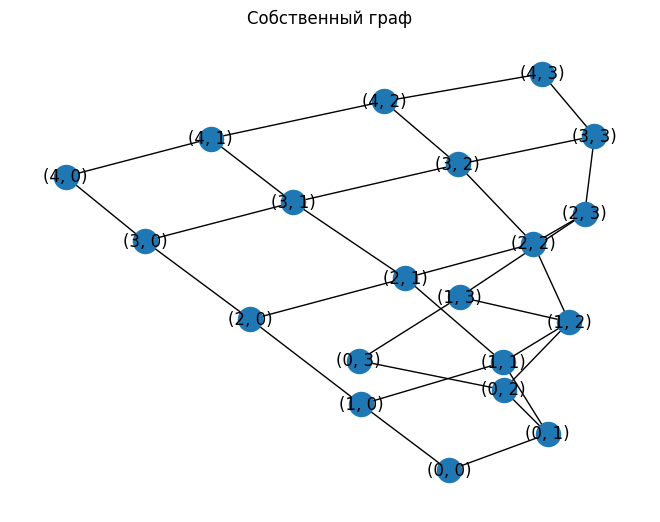

In [5]:
nx.draw(G_custom, with_labels=True)
plt.title("Собственный граф")
plt.show()

In [6]:
# Создаём аналогичный граф с использованием готовой функции networkx
G_builtin = nx.grid_2d_graph(n, m)

print("\nГраф, созданный функцией nx.grid_2d_graph:")
print("Количество узлов:", G_builtin.number_of_nodes())
print("Количество ребер:", G_builtin.number_of_edges())


Граф, созданный функцией nx.grid_2d_graph:
Количество узлов: 20
Количество ребер: 31


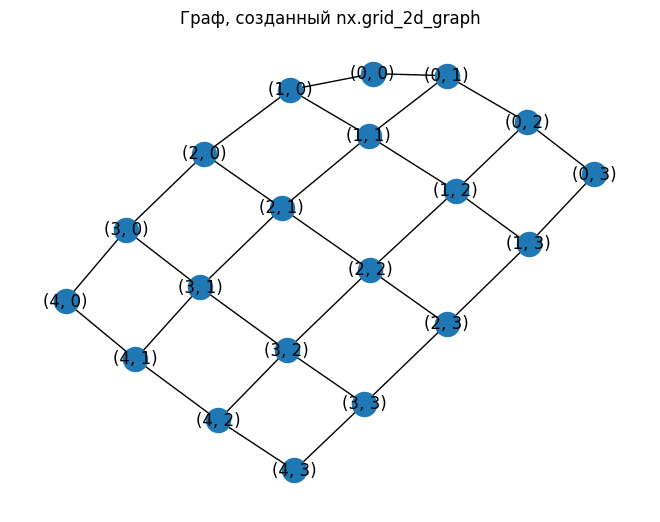

In [7]:
nx.draw(G_builtin, with_labels=True)
plt.title("Граф, созданный nx.grid_2d_graph")
plt.show()

<p class="task" id="4"></p>

4\. Напишите функцию, которая генерирует мультиграф, состоящий из `m` узлов, где количество связей между узлами `u` и `v` сэмплится из биномиального распределения с параметрами `n` и `p` (`m`, `n`, `p` - параметры функции). Петли в графе допускаются. На каждом ребре создайте атрибут `weight`, равный обратному значению количества ребер между индицентными ему узлами. Создайте и визуализируйте граф при помощи функции `nx.draw` с аргументами по умолчанию. Создайте версию графа с удаленными петлями и визуализуйте ее.

- [ ] Проверено на семинаре

In [11]:
def create_multigraph(m, n, p):
    """Генерирует мультиграф с m узлами."""
    G = nx.MultiGraph()
    G.add_nodes_from(range(m))

    # Для каждой пары (u, v), где u <= v, сэмплируем количество ребер
    for u in range(m):
        for v in range(u, m):
            num_edges = np.random.binomial(n, p)
            if num_edges > 0:
                weight = 1 / num_edges  # вес для всех ребер между u и v
                for _ in range(num_edges):
                    G.add_edge(u, v, weight=weight)
    return G

In [12]:
m = 10
n = 5
p = 0.3

In [13]:
# Создаём мультиграф по заданной функции
G_multi = create_multigraph(m, n, p)

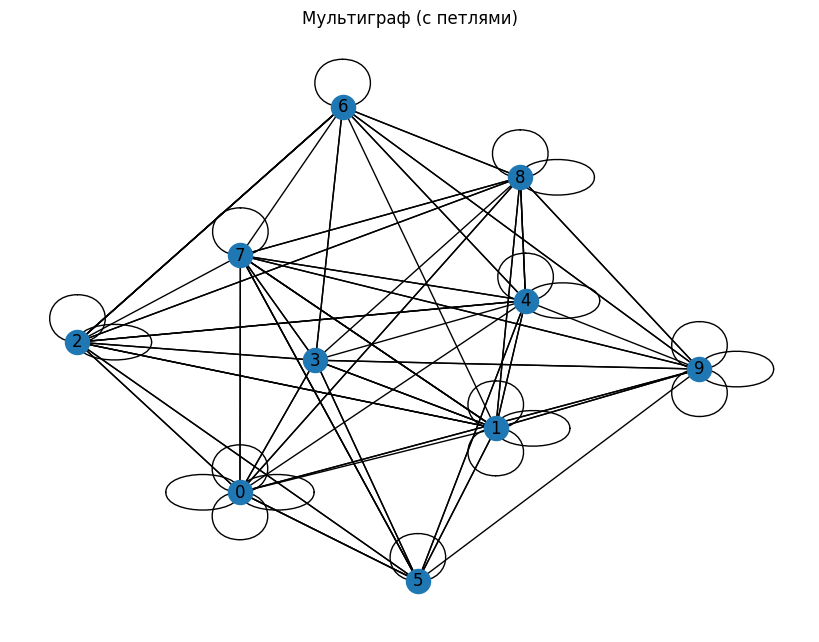

In [14]:
plt.figure(figsize=(8, 6))
nx.draw(G_multi, with_labels=True)
plt.title("Мультиграф (с петлями)")
plt.show()

In [15]:
# Создаем копию графа и удаляем петли (ребра, где оба конца совпадают)
G_no_loops = G_multi.copy()
loops = list(nx.selfloop_edges(G_no_loops, keys=True))
G_no_loops.remove_edges_from(loops)

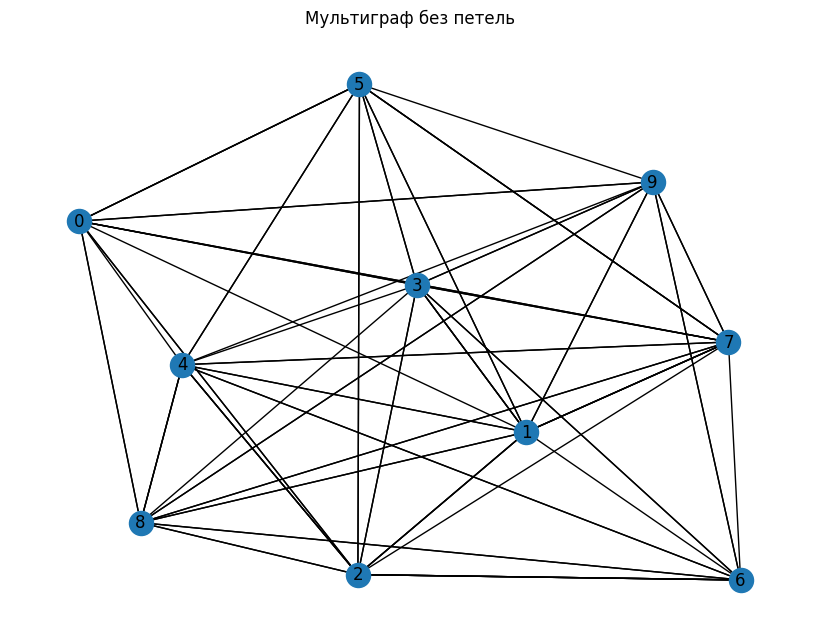

In [16]:
plt.figure(figsize=(8, 6))
nx.draw(G_no_loops, with_labels=True)
plt.title("Мультиграф без петель")
plt.show()

<p class="task" id="5"></p>

5\. Граф «(u,v) цветок»: фрактальный граф, в котором на каждой итерации роста каждая связь заменяется на 2 пути, длиной u и v соответственно (см.рис). Реализуйте функцию построения (1, 2) цветка. Функция принимает один целочисленный параметр `n` - количество шагов построения. Создайте и визуализируйте граф при помощи функции `nx.draw` с аргументами по умолчанию.

![](https://i.imgur.com/aJnbzxM.png)

- [ ] Проверено на семинаре

In [4]:
def build_flower_graph(n):
    G = nx.Graph()
    # Начальная структура: одно ребро между двумя узлами (0,1)
    G.add_edge(0, 1)

    for _ in range(n):
        new_edges = []
        for u, v in list(G.edges()):
            # Разбиваем ребро (u, v) на две последовательности: (u, x), (x, y), (y, v)
            x = max(G.nodes) + 1
            y = x + 1
            new_edges.extend([(u, x), (x, y), (y, v)])
        G.remove_edges_from(list(G.edges()))
        G.add_edges_from(new_edges)

    return G

In [5]:
n = 3

flower_graph = build_flower_graph(n)

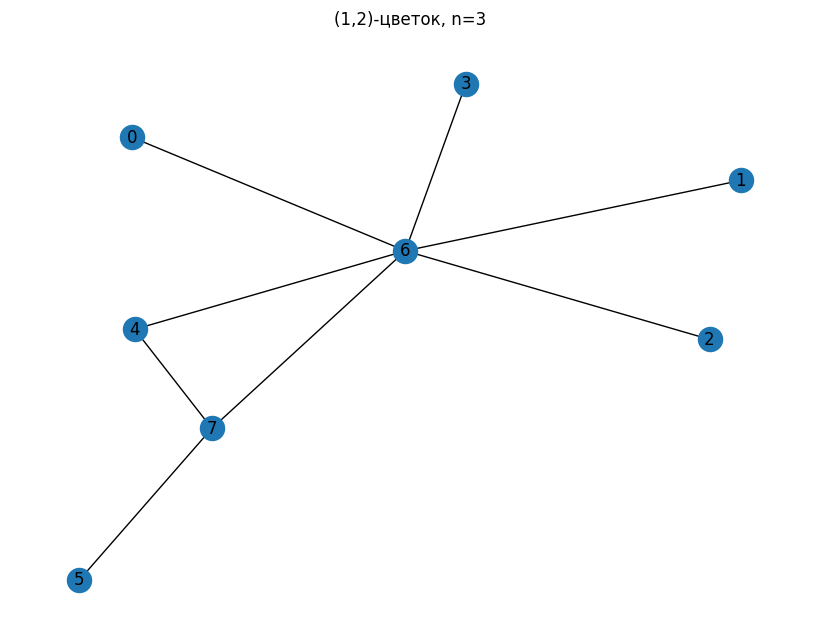

In [6]:
plt.figure(figsize=(8, 6))
nx.draw(flower_graph, with_labels=True, node_size=300)
plt.title(f"(1,2)-цветок, n={n}")
plt.show()